# Сравнительный анализ классической сети и сети с арбитром

Этот скрипт загружает результаты двух симуляций (классической сети и сети с арбитром)
и строит сравнительный график состояния "Ест" для всех пяти философов.
График наглядно показывает разницу: в классической сети наступает deadlock,
а в сети с арбитром — нет.

## Загрузка данных

Подключаем DrWatson и активируем проект.

In [1]:
using DrWatson
@quickactivate "project"

Подключаем библиотеки для работы с таблицами, CSV и графиками.

In [2]:
using DataFrames, CSV, Plots

Загружаем ранее сохранённые результаты симуляций.

In [3]:
df_classic = CSV.read(datadir("dining_classic.csv"), DataFrame)
df_arbiter = CSV.read(datadir("dining_arbiter.csv"), DataFrame)

Row,time,Think_1,Think_2,Think_3,Think_4,Think_5,Hungry_1,Hungry_2,Hungry_3,Hungry_4,Hungry_5,Eat_1,Eat_2,Eat_3,Eat_4,Eat_5,Fork_1,Fork_2,Fork_3,Fork_4,Fork_5,Arbiter
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,4.0
2,0.124923,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,3.0
3,0.285503,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0
4,0.367472,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
5,0.946857,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,1.45161,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2.59507,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
8,2.69306,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9,3.29849,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Количество философов — 5.

In [4]:
N = 5

5

Формируем список столбцов, соответствующих состоянию "Ест" для каждого философа.
В этих столбцах значения: 1 — философ ест, 0 — не ест.

In [5]:
eat_cols = [Symbol("Eat_$i") for i = 1:N]

5-element Vector{Symbol}:
 :Eat_1
 :Eat_2
 :Eat_3
 :Eat_4
 :Eat_5

## Построение графиков

Первый график — классическая сеть.
По горизонтали — время, по вертикали — 1 или 0 (ест или нет).
Каждый философ — линия своего цвета.

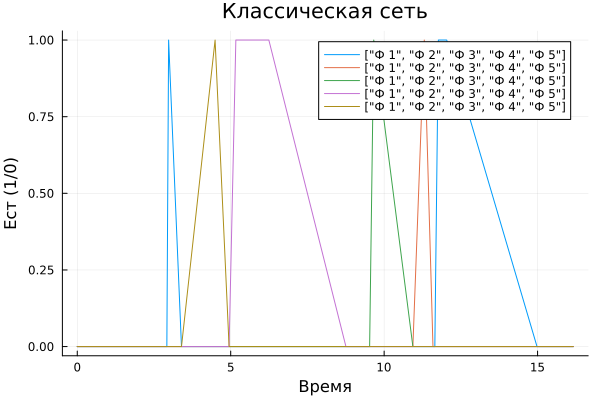

In [6]:
p1 = plot(
    df_classic.time,
    Matrix(df_classic[:, eat_cols]),
    label = ["Ф $i" for i = 1:N],
    xlabel = "Время",
    ylabel = "Ест (1/0)",
    title = "Классическая сеть",
)

Второй график — сеть с арбитром.

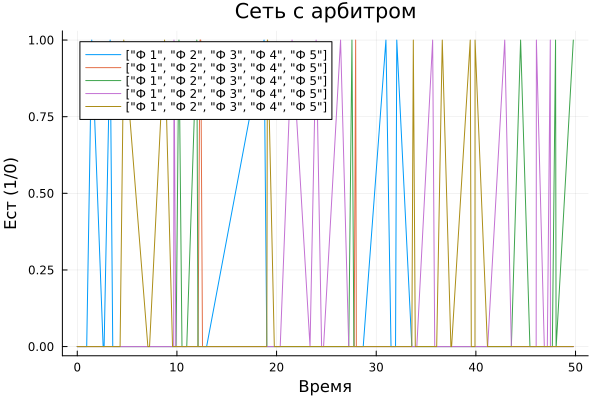

In [7]:
p2 = plot(
    df_arbiter.time,
    Matrix(df_arbiter[:, eat_cols]),
    label = ["Ф $i" for i = 1:N],
    xlabel = "Время",
    ylabel = "Ест (1/0)",
    title = "Сеть с арбитром",
)

Объединяем оба графика в один — один над другим.

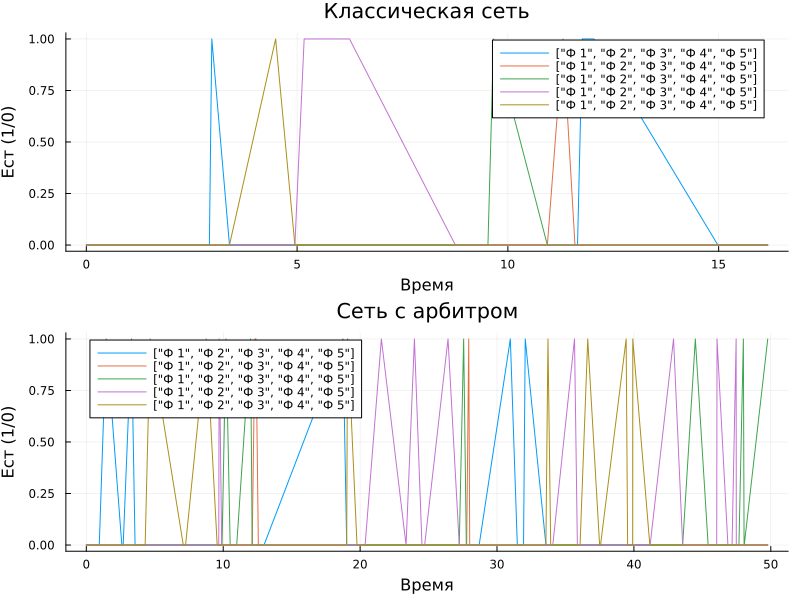

In [8]:
p_final = plot(p1, p2, layout = (2, 1), size = (800, 600))

## Сохранение результата

Сохраняем сравнительный график в папку plots.

In [9]:
#savefig(plotsdir("final_report.png"))

Выводим сообщение об успешном сохранении.

In [10]:
println("Отчёт сохранён в plots/final_report.png")

Отчёт сохранён в plots/final_report.png
